In [25]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.metrics import mean_absolute_percentage_error

import plotly.express as px

random_state = 42

In [3]:
df = pd.read_csv('new_york_listings_2024.csv.zip')
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,...,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license,rating,bedrooms,beds,baths
0,1312228,Rental unit in Brooklyn · ★5.0 · 1 bedroom,7130382,Walter,Brooklyn,Clinton Hill,40.683710,-73.964610,Private room,55.0,...,2015-12-20,0.03,1,0,0,No License,5.0,1,1,Not specified
1,45277537,Rental unit in New York · ★4.67 · 2 bedrooms ·...,51501835,Jeniffer,Manhattan,Hell's Kitchen,40.766610,-73.988100,Entire home/apt,144.0,...,2023-05-01,0.24,139,364,2,No License,4.67,2,1,1
2,971353993633883038,Rental unit in New York · ★4.17 · 1 bedroom · ...,528871354,Joshua,Manhattan,Chelsea,40.750764,-73.994605,Entire home/apt,187.0,...,2023-12-18,1.67,1,343,6,Exempt,4.17,1,2,1
3,3857863,Rental unit in New York · ★4.64 · 1 bedroom · ...,19902271,John And Catherine,Manhattan,Washington Heights,40.835600,-73.942500,Private room,120.0,...,2023-09-17,1.38,2,363,12,No License,4.64,1,1,1
4,40896611,Condo in New York · ★4.91 · Studio · 1 bed · 1...,61391963,Stay With Vibe,Manhattan,Murray Hill,40.751120,-73.978600,Entire home/apt,85.0,...,2023-12-03,0.24,133,335,3,No License,4.91,Studio,1,1


In [14]:
cols_to_drop = ['id', 'name', 'host_id', 'host_name', 'last_review', 'license']

existing_cols_to_drop = [c for c in cols_to_drop if c in df.columns]
df.drop(existing_cols_to_drop, axis=1, inplace=True)
text_columns = df.select_dtypes(include=['object']).columns
print("Оставшиеся текстовые колонки:", text_columns)

cols_to_fix = ['rating', 'bedrooms', 'baths']
for col in cols_to_fix:
    df[col] = df[col].astype(str).str.strip()
    df[col] = df[col].str.extract('(\d+\.?\d*)')[0]
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df[col] = df[col].fillna(df[col].median())
df = pd.get_dummies(df, columns=['neighbourhood_group', 'room_type'])


<>:11: SyntaxWarning: invalid escape sequence '\d'
<>:11: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipython-input-2618885731.py:11: SyntaxWarning: invalid escape sequence '\d'
  df[col] = df[col].str.extract('(\d+\.?\d*)')[0]


Оставшиеся текстовые колонки: Index(['neighbourhood_group', 'room_type', 'rating', 'bedrooms', 'baths'], dtype='object')


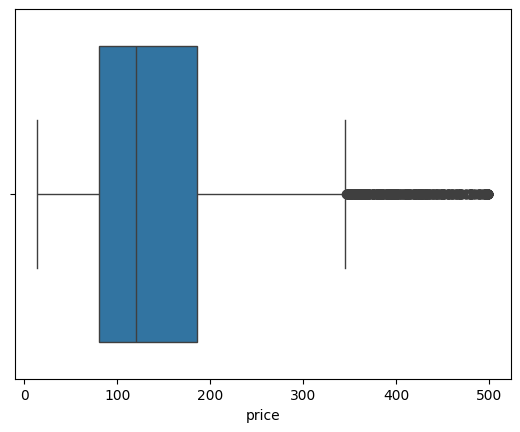

In [16]:
sns.boxplot(x=df['price'])
plt.show()
df = df[(df['price'] > 50) & (df['price'] < 300)]

In [18]:
df.head()

,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,rating,...,baths,neighbourhood_group_Bronx,neighbourhood_group_Brooklyn,neighbourhood_group_Manhattan,neighbourhood_group_Queens,neighbourhood_group_Staten Island,room_type_Entire home/apt,room_type_Hotel room,room_type_Private room,room_type_Shared room
0,40.683710,-73.964610,55.0,30,3,0.03,1,0,0,5.00,...,1.0,False,True,False,False,False,False,False,True,False
1,40.766610,-73.988100,144.0,30,9,0.24,139,364,2,4.67,...,1.0,False,False,True,False,False,True,False,False,False
2,40.750764,-73.994605,187.0,2,6,1.67,1,343,6,4.17,...,1.0,False,False,True,False,False,True,False,False,False
3,40.835600,-73.942500,120.0,30,156,1.38,2,363,12,4.64,...,1.0,False,False,True,False,False,False,False,True,False
4,40.751120,-73.978600,85.0,30,11,0.24,133,335,3,4.91,...,1.0,False,False,True,False,False,True,False,False,False


In [26]:
X = df.drop('price', axis=1)
y = df['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state)

model = RandomForestRegressor(n_estimators=100, random_state=random_state)
model.fit(X_train, y_train)
predictions = model.predict(X_test)

mape = mean_absolute_percentage_error(y_test, predictions)
r2 = r2_score(y_test, predictions)
print(f"MAPE: {mape * 100:.2f}%")
print(f"R^2: {r2:.2f}")

MAPE: 27.60%
R^2: 0.47


In [24]:
df_sample = df.sample(n=5000, random_state=42)

fig = px.scatter_mapbox(
    df_sample,
    lat="latitude",
    lon="longitude",
    color="price",
    size="price",
    color_continuous_scale=px.colors.cyclical.IceFire,
    size_max=15,
    zoom=10,
    mapbox_style="carto-positron",
    title="Распределение цен на Airbnb в Нью-Йорке"
)

fig.update_layout(margin={"r":0,"t":40,"l":0,"b":0})
fig.show()